# GLAM - Exploring Luís Eduardo Magalhães (LEM) / Brazil

**Region:** Luís Eduardo Magalhães (LEM), Bahia, Brazil — a key soy/cotton/maize municipality in the MATOPIBA frontier. 

**Season:** November -> April.  

**Current season:** 2024-2025.

**Data:** MODIS/Terra MOD09Q1 8-day NDVI + CHIRPS 10-day precipitation, served by NASA Harvest GLAM API.  

**Purpose:** Explore the GLAM API

---

## Questions and steps

| Step | Tool | Question |
|------|------|----------|
| 1: Explore | Savitzky-Golay smoothing + percentile band + phenology | What does the current season look like? |
| 2: Diagnostic | Z-score anomaly + STL decomposition | Is something wrong this season? |
| 3: Compare | Pearson correlation + DTW similarity | What past season does this year most resemble? |
| 4: SOM | Self-Organizing Map | Where does this season sit among all historical seasons? |
| 5: Cluster | DTW pairwise heatmap + K-means | Are there natural season types in LEM's history? |
| 6: Trends | Rolling DTW consistency score | Is year-to-year variability changing? |

### Warning

I'm not a specialist in agricultural analysis. To create this analysis I was guided by curiosity, to explore and understand a behavior in a region in Brazil.


---

## Configurations

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from lem.fetch import glam_get_data
from lem.methods import cluster, compare, diagnose, map_som, explore, trend # modules organized/named by question

#
# Target region
#
FEATURE_ID = 2919553                  # Brazilian Institute of Geography and Statistics (IBGE) code: Luís Eduardo Magalhães, Bahia
BOUNDARY_LAYER = "br-municipios-2022" # Brazilian municipalities IBGE database

NDVI_PRODUCT = "mod09q1-ndvi"     # MODIS/Terra 8-day NDVI composite
CHIRPS_PRODUCT = "chirps-precip"  # CHIRPS 10-day dekad precipitation
CROPMASK = "no-mask"

# 
# Season window
#
SEASON_START_MONTH = 11  # November - soy planting begins
SEASON_END_MONTH = 4     # April - harvest complete
CURRENT_YEAR = 2024      # 2024-25 season (Nov 2024 - Apr 2025, complete)

#
# Analysis parameters
#
SAVGOL_WINDOW = 5  # smoothing window in 8-day steps (must be odd)

Z_MILD = -1.0      # mild stress threshold (standard deviations)
Z_SEVERE = -2.0    # severe stress threshold
STL_PERIOD = 46    # expected 8-day observations per calendar year
TOP_N_ANALOGS = 3  # best-match seasons to display

SOM_ROWS = 4       # SOM grid rows
SOM_COLS = 4       # SOM grid columns

N_CLUSTERS = 3     # K-means season types
ROLLING_WINDOW = 3 # seasons for DTW consistency score

#
# Cache
#
CACHE_DIR = Path("cache")

---

## Get GLAM Data

In [2]:
#
# Get Data (we are using mean)
#
ndvi_mat, chirps_mat = glam_get_data(
    cache_dir          = CACHE_DIR,
    ndvi_product       = NDVI_PRODUCT,
    chirps_product     = CHIRPS_PRODUCT,
    feature_id         = FEATURE_ID,
    boundary_layer     = BOUNDARY_LAYER,
    cropmask           = CROPMASK,
    season_start_month = SEASON_START_MONTH,
    season_end_month   = SEASON_END_MONTH,
)

#
# Show data shape
#
print(f"NDVI matrix:   {ndvi_mat.shape}  seasons {ndvi_mat.index.min()}–{ndvi_mat.index.max()}")
print(f"CHIRPS matrix: {chirps_mat.shape}  seasons {chirps_mat.index.min()}–{chirps_mat.index.max()}")

NDVI matrix:   (26, 24)  seasons 1999–2024
CHIRPS matrix: (16, 18)  seasons 2009–2024


---

## Step 1: What does the 2024/2025 season look like?

Here we use raw MODIS 8-day NDVI data, which is often noisy because of clouds and atmospheric effects. To solve this and extract information from the data we:

1. **Smoothing.** Apply a **Savitzky-Golay** filter to clean the noise. It recovers the real shape of the seasonal curve without shifting the timing of the peak.

2. **Comparison.** The smoothed curve is plotted against a historical **percentile band (p25/p50/p75)**, which shows what a typical season looks like at each step of the year.

3. **Metrics.** From the smoothed curve, we extract **phenology metrics**, `SOS` (Start of Season), `Peak`, `EOS` (End of Season), and `length-of-season`, by detecting threshold-crossings. This turns the shape of the curve into numbers that are easy to compare.

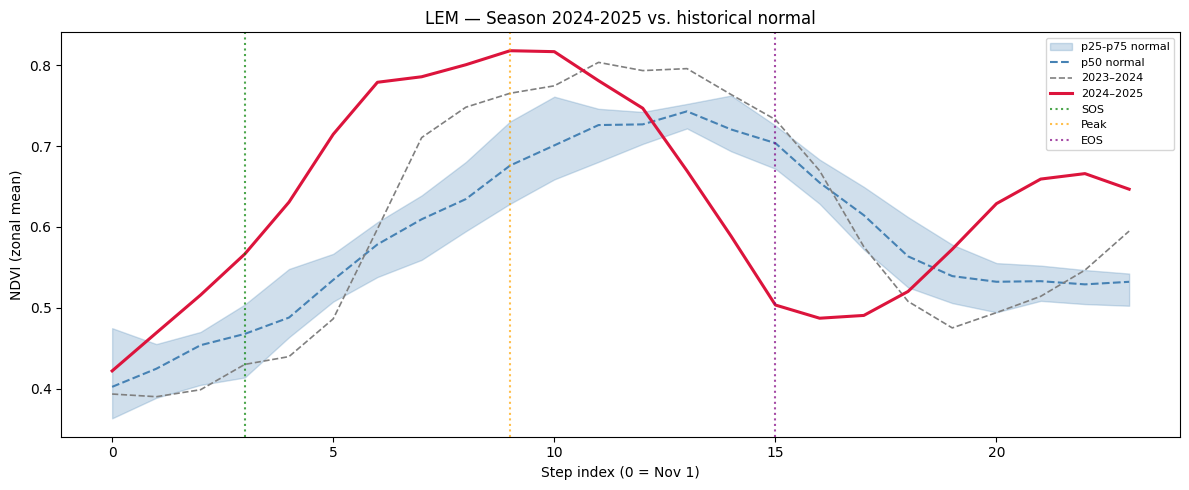

In [3]:
#
# Smooth
#
smooth = explore.smooth_matrix(ndvi_mat, window=SAVGOL_WINDOW)

#
# Phenology
#
phenology = explore.compute_phenology(smooth)

#
# Plot
#
fig = explore.plot_smooth_and_phenology(smooth, phenology, CURRENT_YEAR)
plt.show()

**Interpretation:** Compare the 2024-25 curve against the historical normal data (blue shading = p25-p75, dashed line = median). Vertical markers show where the season crossed the SOS, peak, and EOS thresholds. A curve running above the band throughout the season indicates above normal greenness.

---

## Step 2: Is something wrong this season?

The percentile data from Step 1 shows the *relative* position of the curve, but it doesn't tell us if a value is truly abnormal. To detect stress, we use two extra tools:

1. **Z-score:** For each step, we convert the value into a **Z-score**, which measures how many standard deviations it is from the historical mean. Values below `Z_MILD` indicate **mild stress**, and values below `Z_SEVERE` indicate **severe stress**.

2. **Stress windows:** When 3 or more consecutive steps stay below the threshold, we flag them as a **stress window**, meanint that was a period where the vegetation was struggling.

3. **STL decomposition**: This method fits a trend + seasonal model to the full time series and extracts the residual (what remains after the expected cycle is removed). This reveals structural anomalies that the `Z-score` can miss, because the `Z-score` still contains the seasonal signal. We also overlay the CHIRPS precipitation deviation on the plot, which helps us check if a stress window was caused by low rainfall or by another factor.


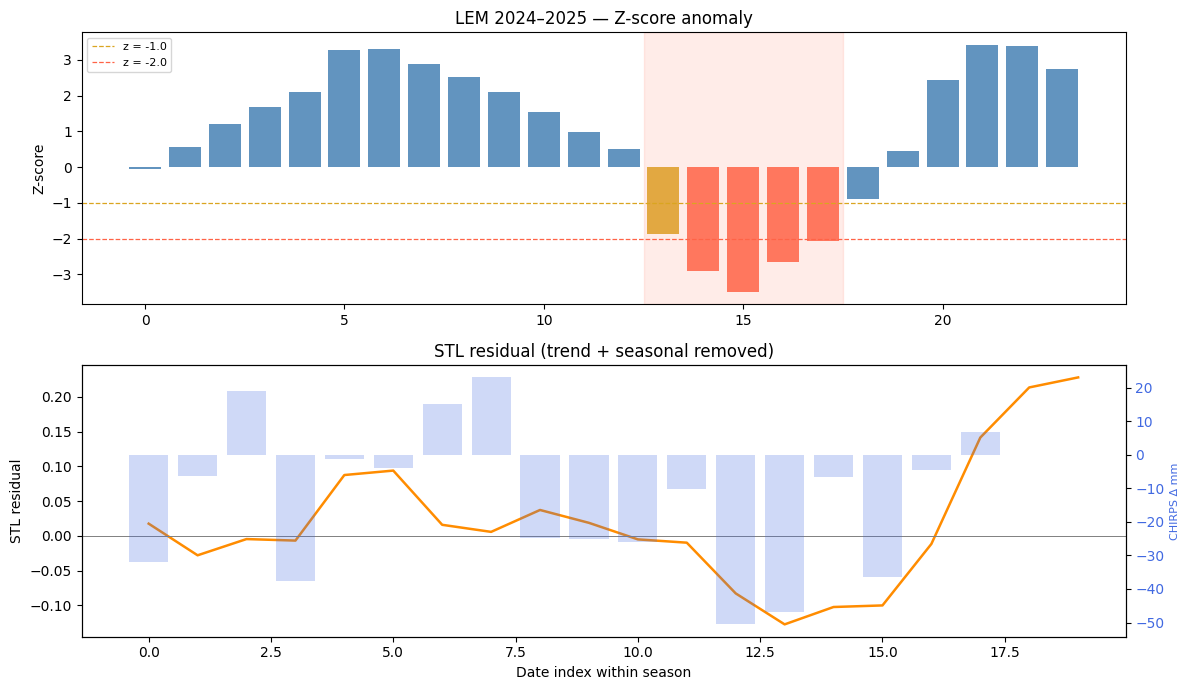

In [4]:
#
# Z-score
#
z_scores, stress_windows = diagnose.compute_zscore(
    smooth,
    CURRENT_YEAR,
    z_mild=Z_MILD,
    z_severe=Z_SEVERE,
)

#
# STL
#
full_ndvi = pd.read_parquet(CACHE_DIR / f"{NDVI_PRODUCT}_{FEATURE_ID}.parquet")
stl_resid = diagnose.compute_stl_residual(full_ndvi, CURRENT_YEAR, period=STL_PERIOD)

#
# Plot
#
fig = diagnose.plot_zscore_and_stl_residual(
    z_scores,
    stl_resid,
    stress_windows,
    chirps_mat,
    CURRENT_YEAR,
    z_mild=Z_MILD,
    z_severe=Z_SEVERE,
)
plt.show()

**Interpretation:** The upper panel bars show `Z-scores` per step. Red shading marks severe stress windows (`z < -2`), yellow marks mild ones (`z < -1`). The second panel shows the STL residual (structural deviation after trend and seasonality are removed) with CHIRPS precipitation deviation in blue. Coincident drops in residual and CHIRPS deficit can indicate stress caused by rainfall.

---

## Step 3: Which past season looks most like 2024/2025?

One useful thing we can do is compare the current year with previous ones to find historical analogs, past seasons that behaved similar to the current year. This helps us anticipate outcomes. For example, if the current season looks like 2018, and 2018 ended with above average yields, that can indicate a useful forecast signal.

To find these historical analogs, we use two complementary tools:

1. **Pearson correlation:** This method measures shape similarity. It rewards seasons that rise and fall at the same time.

2. **DTW (Dynamic Time Warping)**: This method is more flexible. It allows elastic time shifts, so a season with the same overall shape but an earlier or later start can still score as similar.

When the two rankings disagree, that disagreement is informative: it reveals phase shifts, meaning the current season has a similar shape to a past one, but the timing is different.


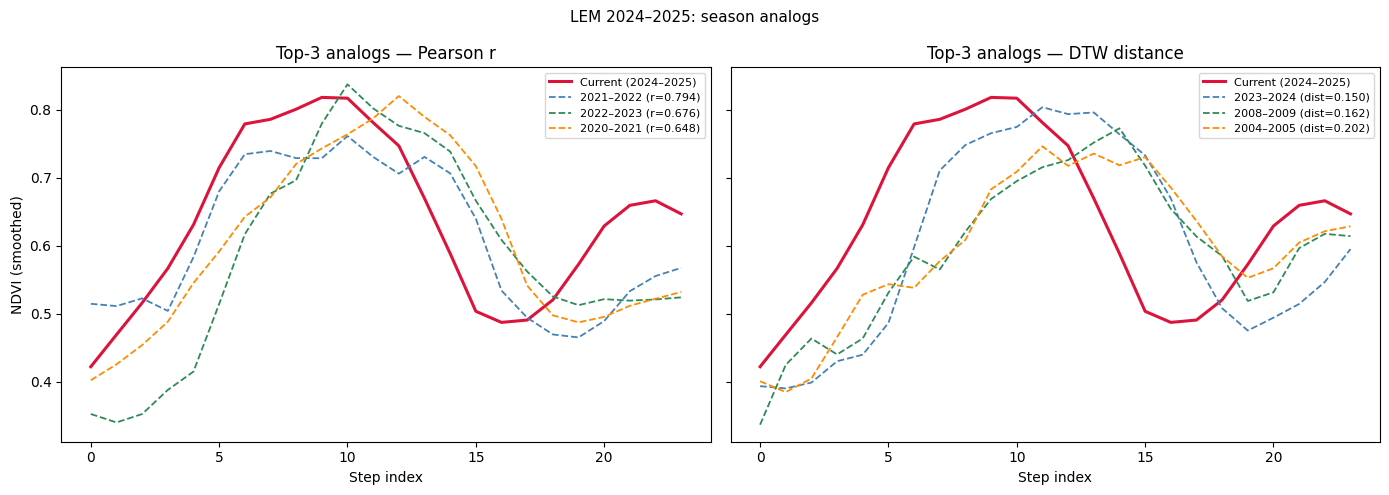

Top-3 analog seasons:
      pearson_year  pearson_r  dtw_year  dtw_dist
rank                                             
1             2021      0.794      2023     0.150
2             2022      0.676      2008     0.162
3             2020      0.648      2004     0.202


In [5]:
#
# Pearson
#
pearson_ranks, dtw_ranks = compare.rank_analogs(smooth, CURRENT_YEAR)

#
# Plot
#
fig_compare = compare.plot_compare(smooth, pearson_ranks, dtw_ranks, CURRENT_YEAR, top_n=TOP_N_ANALOGS)
plt.show()

#
# Summary table
#
analog_table = compare.summary_table(pearson_ranks, dtw_ranks, top_n=TOP_N_ANALOGS)

print(f"Top-{TOP_N_ANALOGS} analog seasons:")
print(analog_table.to_string())

**Interpretation:** Left panel shows the top-3 Pearson analogs and right shows the top-3 DTW analogs. Agreement between methods means the current season closely matches a historical one in both shape and timing. In case of divergences, e.g., different top picks, signals a phase shift: the curve matches one year shape but another year calendar timing.

---

## Step 4: Where does 2024/2025 sit among all historical seasons?

Step 3 gave us point to point analog rankings, showing which past seasons are most similar to the current one. In Step 4, we go beyond and show the *entire distribution* of historical seasons at once. To do this, we use:

1. **Self-Organizing Map (SOM):** A SOM is an unsupervised neural network that places all historical seasons onto a 2D grid, so that nearby cells contain similar seasons. Unlike PCA (which is linear) or K-means (which produces unordered groups), the SOM preserves the neighborhood structure, meaning the distance between cells reflects how different the season types really are.

2. **Reading the map:** Each cell shows the mean NDVI profile of its member seasons as a line plot. The cell that represents the current season is highlighted in red.

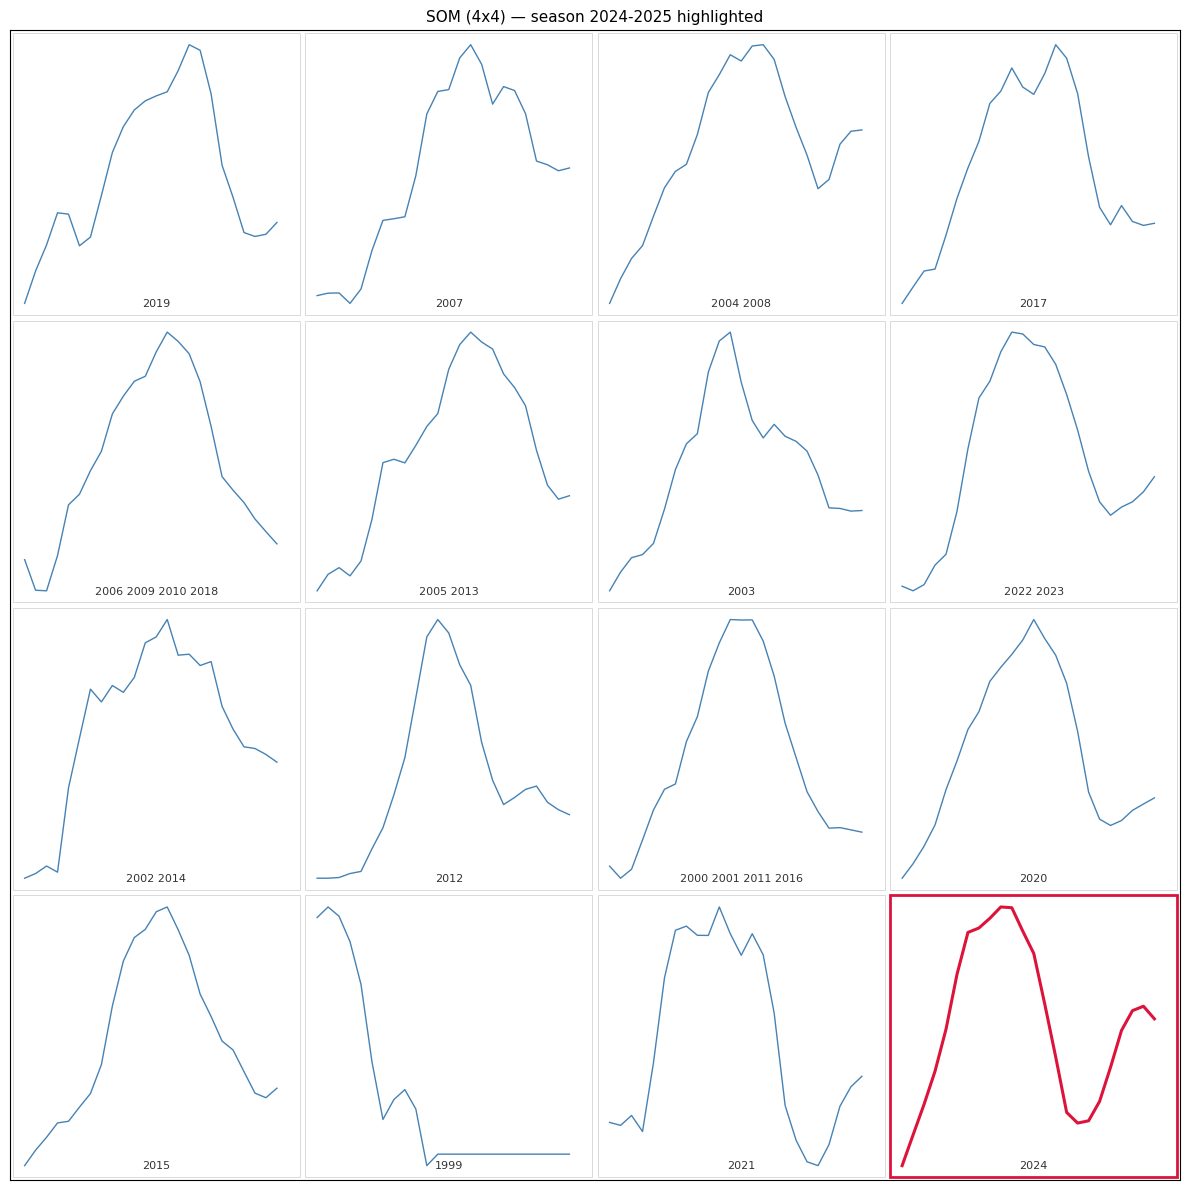

In [6]:
#
# Self-Organized Maps (SOM)
#
som_model, som_scaler, som_data = map_som.fit_som(smooth, rows=SOM_ROWS, cols=SOM_COLS)

#
# Plot
#
fig = map_som.plot_map(smooth, som_model, som_scaler, som_data, CURRENT_YEAR)
plt.show()

**Interpretation:** The current season map is presented in red. Cell labels show which years share that region of the SOM. Neighbouring cells hold seasons with similar (but not identical) profiles. A season in an isolated corner of the grid is structurally unusual; one near the centre is close to the historical average.

---

## Step 5: Are there natural season types in LEM history?

The SOM in Step 4 gives us a continuous map of all seasons. In Step 5, we go one step further and assign *discrete* season type labels, so we can identify clear groups. To do this, we use two complementary tools:

1. **DTW pairwise distance heatmap:** This heatmap shows the raw similarity between every pair of seasons. Dark cells mean two seasons are distant, and bright cells mean they are similar. The advantage is that we don't need any clustering assumption to read it. Natural groups appear directly in the heatmap.

2. **K-means clustering:** This method assigns `N_CLUSTERS` discrete labels to the standardized season curves. The tradeoff is that K-means uses Euclidean distance, so two seasons with similar shapes but different timing (phase shifts) can end up in different clusters.


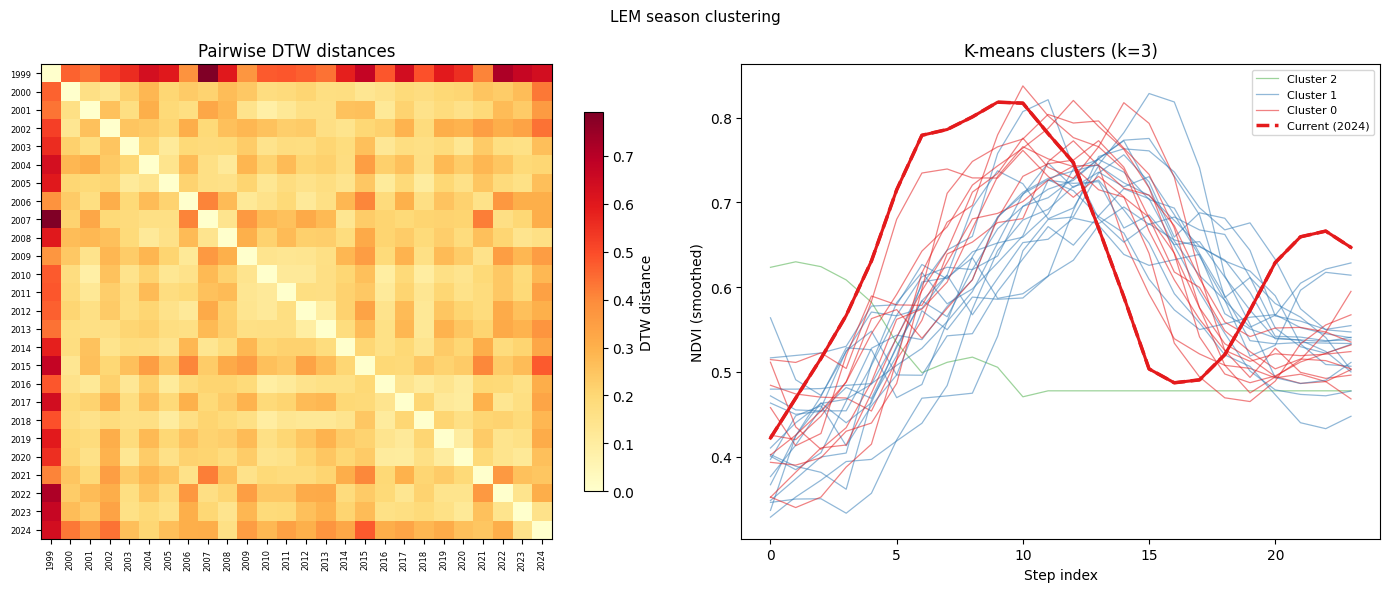


K-means cluster membership:
  Cluster 0: [2001, 2011, 2016, 2017, 2018, 2020, 2021, 2022, 2023, 2024]
  Cluster 1: [2000, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2012, 2013, 2014, 2015, 2019]
  Cluster 2: [1999]


In [7]:
#
# DTW Matrix
#
dist_matrix = cluster.compute_dtw_matrix(smooth)

#
# K-Means
#
kmeans_labels = cluster.compute_kmeans_clusters(smooth, n_clusters=N_CLUSTERS)

#
# Plot
#
fig = cluster.plot_cluster(smooth, dist_matrix, kmeans_labels, CURRENT_YEAR)
plt.show()

#
# Extra details
#
years = smooth.index.tolist()
curr_idx = years.index(CURRENT_YEAR)

print("\nK-means cluster membership:")
for lbl in sorted(set(int(l) for l in kmeans_labels)):
    members = [yr for yr, kl in zip(years, kmeans_labels) if int(kl) == lbl]
    print(f"  Cluster {lbl}: {members}")

**Interpretation:** Left (DTW heatmap). Brighter blocks along the diagonal indicate periods of similar seasons. A dark row or column marks an anomalous year that differs from all the others. Right (K-means clusters). Each season curve is colored by its cluster assignment. The current season is highlighted with a bold red line.

---

## Step 6: Is year to year variability changing?

Previous steps measured the *level* of NDVI (how high or low it is). In this step, we measure something different: how *similar* each season is to the ones around it. For this, we use:

1. **Rolling DTW consistency score:** For each season, the score is calculated as the mean DTW distance to the nearest `ROLLING_WINDOW` surrounding years. In other words, we check how much each season differs from its temporal neighbors. A `rising score` means seasons are becoming less predictable, even if the average NDVI stays the same. A `declining score` means the agricultural system is becoming more consistent from year to year, a signal of stabilization.

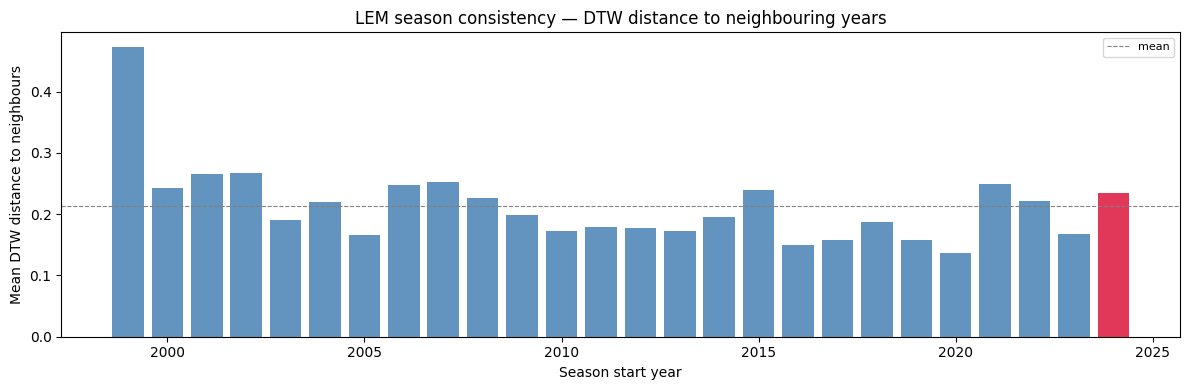

DTW consistency scores (mean DTW distance to neighbouring seasons):
1999    0.473
2000    0.243
2001    0.266
2002    0.267
2003    0.190
2004    0.220
2005    0.166
2006    0.247
2007    0.253
2008    0.227
2009    0.199
2010    0.172
2011    0.178
2012    0.178
2013    0.173
2014    0.195
2015    0.240
2016    0.150
2017    0.158
2018    0.187
2019    0.157
2020    0.137
2021    0.250
2022    0.221
2023    0.168
2024    0.235


In [8]:

#
# DTW distances
#
dtw_series = trend.compute_dtw_series(smooth, rolling_window=ROLLING_WINDOW)

#
# Plot
#
fig = trend.plot_trend(dtw_series, CURRENT_YEAR)
plt.show()

#
# Extra information
#
print("DTW consistency scores (mean DTW distance to neighbouring seasons):")
print(dtw_series.round(3).to_string())

**Interpretation.** Each bar shows how *different* that season was from its neighbours. The red bar is the current season. Bars above the dashed mean line indicate seasons that stand out from surrounding years, potential anomalies or transitions. A downward slope in the bar heights over time would indicate that seasons are becoming more homogeneous.